# **Thông tin nhóm**
- Lớp: ML 23KHDL1
- Nhóm: 6
- Sinh viên:
    - 23127102 - Lê Quang Phúc
    - 23127212 - Nguyễn Quang Đăng Khoa
    - 23127241 - Đoàn Thành Phát
    - 23127332 - Trần Tiến Cường
    - 23127442 - Trầm Hữu Nhân

# **Thực hiện finetune và đánh giá đối với mô hình GLMOCR**
Notebook này trình bày quy trình **finetune** và **đánh giá** mô hình GLMOCR cho bài toán nhận diện ký tự quang học (OCR) tiếng Việt. Khác với quá trìh đánh giá baseline, finetune mô hình lớn đòi hỏi sử dụng các kỹ thuật tối ưu tài nguyên như `PEFT` (Parameter efficient fine-tuning), cụ thể là `LoRA` (Low-rank adaptation) kết hợp `lượng tử hóa` (Quantization)

Toàn bộ pipeline được xây dựng và thực thi trên framework `LLaMA-Factory` – một nền tảng hỗ trợ huấn luyện, tinh chỉnh và triển khai các mô hình ngôn ngữ lớn hiện đại, giúp tự động hóa các bước xử lý dữ liệu, cấu hình huấn luyện, lưu checkpoint và đánh giá mô hình.



## 1. Cài đặt thư viện và môi trường

In [ ]:
!pip install -q -U transformers accelerate tiktoken
!pip install -q bitsandbytes peft trl
!pip install -q Levenshtein editdistance pandas tqdm
!pip install --upgrade transformers peft accelerate
!pip install -U "peft>=0.10.0"
!pip install -U torchao

### 1.1 Mount tới Google Drive để lấy dataset

Do tập dữ liệu có kích thước lớn, việc đọc trực tiếp từ **Google Drive** có thể gây ra hiện tượng thắt nút cổ chai băng thông làm chậm đáng kể quá trình suy luận của mô hình. Nên là:
- **Mount Google Drive** để lấy file nén `processed_data.zip`.
- **Giải nén trực tiếp vào bộ nhớ cục bộ** của máy ảo Colab (`/content/local_data`). Thao tác này giúp thao tác đọc ảnh trong vòng lặp đánh giá sau này đạt tốc độ tối đa.

In [1]:
import os
import json
import shutil
import yaml
import torch
import importlib
import subprocess
import sys
import tqdm
import re
import unicodedata
import pandas as pd
import Levenshtein
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from google.colab import drive
from peft import AutoPeftModelForCausalLM, PeftModel
from transformers import AutoProcessor, AutoConfig
from PIL import Image

drive.mount('/content/drive')

ZIP_PATH = Path('/content/drive/MyDrive/IntroToML - OCR - data/processed_data.zip')
LOCAL_ROOT = Path('/content/local_data')

WORK_DIR        = "/content/ocr_project"
DATASET_DIR     = os.path.join(WORK_DIR, "dataset")
LLAMAFACTORY_DIR = "/content/LLaMA-Factory"

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(DATASET_DIR, exist_ok=True)

if ZIP_PATH.exists():
    if not LOCAL_ROOT.exists():
        !unzip -q "{ZIP_PATH}" -d "{LOCAL_ROOT}"
    else:
        print("Dữ liệu đã có sẵn.")
else:
    print(f"❌ LỖI: Không tìm thấy file {ZIP_PATH}")

TRAIN_DIR = LOCAL_ROOT / 'train'
VALID_DIR = LOCAL_ROOT / 'valid'
TEST_DIR  = LOCAL_ROOT / 'test'

print(f"\nĐường dẫn thư mục Train: {TRAIN_DIR}")
print(f"Đường dẫn thư mục Valid: {VALID_DIR}")
print(f"Đường dẫn thư mục Test: {TEST_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dữ liệu đã có sẵn.

Đường dẫn thư mục Train: /content/local_data/train
Đường dẫn thư mục Valid: /content/local_data/valid
Đường dẫn thư mục Test: /content/local_data/test


## 2. Chuyển đổi dataset sang định dạng ShareGPT

Mô hình `GLMOCR` là một mô hình sinh văn bản đa phương thức, do đó mô hình yêu cầu đầu vào phải định dạng lại tập dữ liệu đã chuẩn bị ở bước trước thành cấu trúc hội thoại (message) chuẩn của mô hình.

Mỗi mẫu dữ liệu sẽ được cấu trúc gồm:
- **User role:** Hình ảnh đầu vào + câu lệnh (prompt) yêu cầu nhận dạng chữ.
- **Assistant role:** Văn bản thực tế (grouth truth) tương ứng của bức ảnh.


### 2.1 Các hàm hỗ trợ

In [2]:
IMAGE_FOLDER_NAME = "viet_ocr"
IMG_COPY_DIR = os.path.join(DATASET_DIR, IMAGE_FOLDER_NAME)
os.makedirs(IMG_COPY_DIR, exist_ok=True)

def load_labels(label_path):
    with open(label_path, 'r', encoding='utf-8') as f:
        return json.load(f)


def process_split(split_dir, split_name, img_copy_dir, image_folder_name, max_samples=None):
    samples = []
    errors  = []
    split_path = Path(split_dir)

    # Gom toàn bộ thư mục con và label.json
    sub_dirs = []
    for sub in sorted(split_path.iterdir()):
        if sub.is_dir():
            label_file = sub / "label.json"
            if label_file.exists():
                sub_dirs.append((sub, load_labels(label_file)))
            else:
                print(f"Không có label.json trong {sub}")

    # Xử lý và copy ảnh với giới hạn max_samples
    sample_count = 0

    for folder, label_map in tqdm(sub_dirs, desc=f"Xử lý {split_name}"):
        # Nếu đã đạt đủ số lượng yêu cầu thì thoát vòng lặp ngoài
        if max_samples and sample_count >= max_samples:
            break

        for img_name, ground_truth in label_map.items():
            # Kiểm tra thêm lần nữa ở vòng lặp trong
            if max_samples and sample_count >= max_samples:
                break

            src_img = folder / img_name
            if not src_img.exists():
                errors.append(str(src_img))
                continue

            new_img_name = f"{split_name}_{folder.name}_{img_name}"

            dst_img = Path(img_copy_dir) / new_img_name
            if not dst_img.exists():
                shutil.copy2(src_img, dst_img)

            rel_path = f"{image_folder_name}/{new_img_name}"
            sample = {
                "messages": [
                    {"role": "user",      "content": "<image>Text Recognition:"},
                    {"role": "assistant", "content": str(ground_truth).strip()}
                ],
                "images": [rel_path]
            }
            samples.append(sample)
            sample_count += 1

    return samples, errors

train_samples, train_errors = process_split(TRAIN_DIR, "train", IMG_COPY_DIR, IMAGE_FOLDER_NAME, max_samples=1000)
valid_samples, valid_errors = process_split(VALID_DIR, "valid", IMG_COPY_DIR, IMAGE_FOLDER_NAME, max_samples=200)
test_samples, test_errors = process_split(TEST_DIR, "test", IMG_COPY_DIR, IMAGE_FOLDER_NAME, max_samples=200)

Xử lý test:   1%|▏         | 2/150 [00:00<00:02, 69.90it/s]


### 2.2 Thực hiện việc chuyển đổi

In [4]:
train_json_path = os.path.join(DATASET_DIR, "viet_ocr_train.json")
valid_json_path = os.path.join(DATASET_DIR, "viet_ocr_valid.json")
test_json_path  = os.path.join(DATASET_DIR, "viet_ocr_test.json")

with open(train_json_path, 'w', encoding='utf-8') as f:
    json.dump(train_samples, f, ensure_ascii=False, indent=2)

with open(valid_json_path, 'w', encoding='utf-8') as f:
    json.dump(valid_samples, f, ensure_ascii=False, indent=2)

with open(test_json_path, 'w', encoding='utf-8') as f:
    json.dump(test_samples, f, ensure_ascii=False, indent=2)

print(f"Đường dẫn của tập train sau khi chuyển sang ShareGPT: {train_json_path}")
print(f"Đường dẫn của tập valid sau khi chuyển sang ShareGPT: {valid_json_path}")
print(f"Đường dẫn của tập test sau khi chuyển sang ShareGPT: {test_json_path}")

Đường dẫn của tập train sau khi chuyển sang ShareGPT: /content/ocr_project/dataset/viet_ocr_train.json
Đường dẫn của tập valid sau khi chuyển sang ShareGPT: /content/ocr_project/dataset/viet_ocr_valid.json
Đường dẫn của tập test sau khi chuyển sang ShareGPT: /content/ocr_project/dataset/viet_ocr_test.json


## 3. Thực hiện đánh giá mô hình baseline GLMOCR
Việc thực hiện đánh giá mô hình cũng được thực hiện giống với notebook `baseline_GLMOCR.ipynb`, để quá trình đánh giá được diễn ra nhanh chóng, ở bước đánh giá này chỉ đánh giá trên tập `Test` gồm `max_samples=200` dữ liệu ở định dạng **ShareGPT** (cho thống nhất với khi đánh giá sau khi đã finetune mô hình)

### 3.1 Các hàm hỗ trợ

In [3]:
def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFC', text)
    return text.strip().lower()

def calculate_cer(pred: str, gt: str) -> float:
    pred = normalize_text(pred)
    gt = normalize_text(gt)

    if len(gt) == 0:
        return 1.0 if len(pred) > 0 else 0.0

    edit_dist = Levenshtein.distance(pred, gt)
    cer = edit_dist / len(gt)
    return cer

def _run_ocr_glm(model, processor, image, target_height=112, max_width=1120):
    orig_w, orig_h = image.size
    scale = target_height / orig_h
    new_w = max(28, (min(int(orig_w * scale), max_width) // 28) * 28)
    new_h = max(28, (int(orig_h * scale) // 28) * 28)
    image = image.resize((new_w, new_h), Image.LANCZOS)

    device = model.device

    # Cấu trúc hội thoại chuẩn của nhóm tác giả
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": "Text Recognition:"}
        ]
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt").to(device)

    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=256, do_sample=False)

    generated = out[0][inputs["input_ids"].shape[1]:]
    return processor.tokenizer.decode(generated, skip_special_tokens=True).strip()

### 3.2 Khởi tạo và đánh giá mô hình

In [6]:
# Khởi tạo mô hình
DATASET_DIR = "/content/ocr_project/dataset"
TEST_JSON_PATH = os.path.join(DATASET_DIR, "viet_ocr_test.json")

print("Đang nạp mô hình GLMOCR...")
BASE_MODEL = "zai-org/GLM-OCR"

cfg = AutoConfig.from_pretrained(BASE_MODEL, trust_remote_code=True)
module = importlib.import_module(f"transformers.models.{cfg.model_type.replace('-', '_')}")
gen_cls = next(
    (getattr(module, a) for a in dir(module) if "ForConditionalGeneration" in a),
    None
)

processor = AutoProcessor.from_pretrained(BASE_MODEL, trust_remote_code=True)

model = gen_cls.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    torch_dtype=torch.float16,
    device_map="auto"
).eval()

with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    all_test_samples = json.load(f)

print(f"Thực hiện đánh giá trên {len(all_test_samples)} ảnh \n")

# Vòng lặp suy luận
total_cer = 0.0
error_logs = []

for sample in tqdm(all_test_samples, desc="Đang đánh giá"):
    img_rel_path = sample["images"][0]
    gt_text = sample["messages"][1]["content"]

    img_path = os.path.join(DATASET_DIR, img_rel_path)
    try:
        img = Image.open(str(img_path))

        pred_text = _run_ocr_glm(model, processor, img)
    except Exception as e:
        pred_text = ""

    # Tính CER
    cer_score = calculate_cer(pred_text, gt_text)
    total_cer += cer_score

    if cer_score > 0:
        error_logs.append({
            "image": os.path.basename(img_path),
            "ground_truth": normalize_text(gt_text),
            "prediction": normalize_text(pred_text),
            "cer_score": round(cer_score, 4)
        })

# Kết quả tổng kết
test_samples = len(all_test_samples)
average_cer = total_cer / test_samples if test_samples > 0 else 0
print(f"\nCER trung bình: {average_cer * 100:.2f} %")
print(f"Số lượng ảnh dự đoán sai: {len(error_logs)}")

Đang nạp mô hình GLMOCR...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/510 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/165 [00:00<?, ?B/s]

Thực hiện đánh giá trên 200 ảnh 



Đang đánh giá: 100%|██████████| 200/200 [01:50<00:00,  1.81it/s]


CER trung bình: 85.00 %
Số lượng ảnh dự đoán sai: 163


### 3.3 Lữu trữ kết quả

In [7]:
# Chuyển đổi danh sách lỗi thành Pandas DataFrame
df_errors = pd.DataFrame(error_logs)

# Sắp xếp từ lỗi nặng nhất xuống nhẹ nhất
df_errors = df_errors.sort_values(by="cer_score", ascending=False)

# Lưu file nội bộ
report_path = LOCAL_ROOT / 'baseline.csv'
df_errors.to_csv(report_path, index=False, encoding='utf-8-sig')

# Copy sang Google Drive
drive_report_path = Path('/content/drive/MyDrive/IntroToML - OCR - data/baseline.csv')
!cp "{report_path}" "{drive_report_path}"

print(f"Đã lưu lại report của baseline")

Đã lưu lại report của baseline


## 4. Tải và cài đặt LLaMA-Factory

In [8]:
%%bash
# Clone LLaMA-Factory
if [ ! -d "/content/LLaMA-Factory" ]; then
    git clone --depth 1 https://github.com/hiyouga/LLaMA-Factory.git /content/LLaMA-Factory
    echo "Đã clone thư mục LLaMA-Factory"
else
    echo "LLaMA-Factory đã tồn tại"
fi

Đã clone thư mục LLaMA-Factory


Cloning into '/content/LLaMA-Factory'...


In [9]:
%%bash
cd /content/LLaMA-Factory
pip install -e . -q
pip install -r requirements/metrics.txt -q
echo "Đã cài đặt LLaMA-Factory"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 107.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 129.3 MB/s eta 0:00:00
Đã cài đặt LLaMA-Factory


In [10]:
%%bash
# Nang cap transformers de ho tro GLM-OCR
pip install --upgrade transformers -q
echo "Đã nâng cấp transformers."
python -c "import transformers; print('Transformers version:', transformers.__version__)"

Đã nâng cấp transformers.
Transformers version: 5.5.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llamafactory 0.9.5.dev0 requires transformers!=4.52.0,!=4.57.0,<=5.2.0,>=4.55.0, but you have transformers 5.5.4 which is incompatible.


In [11]:
%%bash
llamafactory-cli version

----------------------------------------------------------
| Welcome to LLaMA Factory, version 0.9.5.dev0           |
|                                                        |
| Project page: https://github.com/hiyouga/LLaMA-Factory |
----------------------------------------------------------


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


## 5. Đăng ký dataset
Đăng ký thông tin dataset vào file `dataaset_info.json` để **LLaMA-Factory** nhận diện và sử dụng đúng định dạng dữ liệu

In [12]:
# Đường dẫn
LLAMAFACTORY_DATA_DIR = "/content/LLaMA-Factory/data"
IMAGE_FOLDER_NAME     = "viet_ocr"

for fname in ["viet_ocr_train.json", "viet_ocr_valid.json", "viet_ocr_test.json"]:
    src = os.path.join(DATASET_DIR, fname)
    dst = os.path.join(LLAMAFACTORY_DATA_DIR, fname)
    shutil.copy2(src, dst)

img_dst = os.path.join(LLAMAFACTORY_DATA_DIR, IMAGE_FOLDER_NAME)
if os.path.exists(img_dst):
    shutil.rmtree(img_dst)
shutil.copytree(IMG_COPY_DIR, img_dst)

# Đăng ký dataset vào dataset_info.json của LLaMA-Factory
dataset_info_path = os.path.join(LLAMAFACTORY_DATA_DIR, "dataset_info.json")

with open(dataset_info_path, 'r', encoding='utf-8') as f:
    dataset_info = json.load(f)

for split_name, json_file in [("viet_ocr_train", "viet_ocr_train.json"),
                               ("viet_ocr_valid",  "viet_ocr_valid.json"),
                                ("viet_ocr_test",  "viet_ocr_test.json")]:
    dataset_info[split_name] = {
        "file_name": json_file,
        "formatting": "sharegpt",
        "columns": {
            "messages": "messages",
            "images":   "images"
        },
        "tags": {
            "role_tag":      "role",
            "content_tag":   "content",
            "user_tag":      "user",
            "assistant_tag": "assistant"
        }
    }
    print(f"Đã đăng ký dataset: {split_name}")

with open(dataset_info_path, 'w', encoding='utf-8') as f:
    json.dump(dataset_info, f, ensure_ascii=False, indent=2)


Đã đăng ký dataset: viet_ocr_train
Đã đăng ký dataset: viet_ocr_valid
Đã đăng ký dataset: viet_ocr_test


## 6. Resume checkpoint
Được thiết kế để quản lý việc khôi phục và tiếp tục quá trình huấn luyện từ điểm checkpoint đã lưu trước đó (bằng cách sử dụng biến `RESUME_TRAINING`)
- Hỗ trợ tiếp tục huấn luyện từ checkpoint trước đó (nếu có), giúp tiết kiệm thời gian và tài nguyên khi huấn luyện mô hình lớn.
- Tự động tìm checkpoint mới nhất trong Google Drive, copy về local, và cập nhật đường dẫn cho quá trình huấn luyện.

In [13]:
# True - nếu huấn luyện tiếp từ checkpoint, False - huấn luyện từ đầu
RESUME_TRAINING = True

DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/IntroToML - OCR - data/lora_adapter"
RESUME_CHECKPOINT_PATH = None   # Se duoc set tu dong o duoi

if RESUME_TRAINING:
    drive_path = Path(DRIVE_CHECKPOINT_DIR)
    if not drive_path.exists():
        raise FileNotFoundError(
            f"Không tìm thấy checkpoint: {DRIVE_CHECKPOINT_DIR}")

    # Tìm checkpoint mới nhất
    checkpoints = sorted(
        [d for d in drive_path.iterdir() if d.is_dir() and d.name.startswith("checkpoint-")],
        key=lambda d: int(d.name.split("-")[1])
    )

    if not checkpoints:
        # Khong co folder checkpoint-xxx, thu dung chinh thu muc do (LoRA adapter truc tiep)
        # Truong hop nay xay ra khi luu adapter sau khi train xong (khong co checkpoint giua chung)
        if (drive_path / "adapter_config.json").exists():
            RESUME_CHECKPOINT_PATH = str(drive_path)
            print(f"Dung LoRA adapter truc tiep: {RESUME_CHECKPOINT_PATH}")
        else:
            raise FileNotFoundError(
                f"Khong tim thay checkpoint hoac adapter trong: {DRIVE_CHECKPOINT_DIR}\n"
                "Dam bao thu muc chua 'checkpoint-xxx' hoac 'adapter_config.json'."
            )
    else:
        RESUME_CHECKPOINT_PATH = str(checkpoints[-1])
        print(f"Tìm thấy {len(checkpoints)} checkpoint(s).")
        for ck in checkpoints:
            print(f"  - {ck.name}")
        print(f"\nSẽ bắt đầu huấn luyện tiếp tục từ checkpoint: {checkpoints[-1].name}")

    # Copy checkpoint từ Google Drive về local
    LOCAL_CHECKPOINT_DIR = "/content/LLaMA-Factory/saves/glm-ocr/lora/sft"
    if Path(LOCAL_CHECKPOINT_DIR).exists():
        shutil.rmtree(LOCAL_CHECKPOINT_DIR)
    shutil.copytree(drive_path, LOCAL_CHECKPOINT_DIR)

    # Cap nhat RESUME_CHECKPOINT_PATH sang duong dan local
    if checkpoints:
        RESUME_CHECKPOINT_PATH = str(
            Path(LOCAL_CHECKPOINT_DIR) / checkpoints[-1].name
        )
    else:
        RESUME_CHECKPOINT_PATH = LOCAL_CHECKPOINT_DIR
else:
    print("Huấn luyện từ đầu")

Tìm thấy 5 checkpoint(s).
  - checkpoint-100
  - checkpoint-189
  - checkpoint-200
  - checkpoint-300
  - checkpoint-375

Sẽ bắt đầu huấn luyện tiếp tục từ checkpoint: checkpoint-375


## 7. Thực hiện finetune GLMOCR

### 7.1 Cấu hình huấn luyện
- Định nghĩa các tham số huấn luyện, phương pháp finetune (sử dụng `LoRa`), epoch, batch size, learning rate, số lượng mẫu, độ dài tối đa,...
- Tạo file cấu hình `YAML` cho **LLaMA-Factory** dựa trên các tham số trên
- Cập nhận được dẫn checkpoint (nếu có)

In [14]:
FINETUNE_METHOD = "lora"
NUM_EPOCHS      = 3
BATCH_SIZE      = 2
GRAD_ACCUM      = 4             # Effective batch = BATCH_SIZE x GRAD_ACCUM
MAX_SAMPLES     = 1000          # None = dùng toàn bộ dữ liệu, số nguyên - dùng N dữ liệu
CUTOFF_LEN      = 2048
OUTPUT_DIR_NAME = f"saves/glm-ocr/{FINETUNE_METHOD}/sft"
LR = 1e-4 if FINETUNE_METHOD == "lora" else 1e-5

YAML_PATH = f"/content/LLaMA-Factory/glm_ocr_{FINETUNE_METHOD}_sft.yaml"

config = {
    # Mô hình
    "model_name_or_path": "zai-org/GLM-OCR",
    "trust_remote_code": True,

    # Phương pháp
    "stage": "sft",
    "do_train": True,
    "finetuning_type": FINETUNE_METHOD,

    # Dữ liệu
    "dataset": "viet_ocr_train",
    "template": "glm_ocr",
    "cutoff_len": CUTOFF_LEN,
    "preprocessing_num_workers": 2,
    "dataloader_num_workers": 2,

    # Đầu ra
    "output_dir": OUTPUT_DIR_NAME,
    "logging_steps": 10,
    "save_steps": 100,
    "plot_loss": True,
    "overwrite_output_dir": True,
    "save_only_model": False,
    "report_to": "none",

    # Huấn luyện
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": 1,
    "gradient_accumulation_steps": GRAD_ACCUM,
    "learning_rate": LR,
    "num_train_epochs": NUM_EPOCHS,
    "lr_scheduler_type": "cosine",
    "warmup_ratio": 0.1,
    "bf16": True,
    "ddp_timeout": 180000000,
    "resume_from_checkpoint": None,

    # Tối ưu bộ nhớ
    "quantization_bit": 8,
}

if MAX_SAMPLES is not None:
    config["max_samples"] = MAX_SAMPLES

# Tham so rieng cho tung phuong phap
if FINETUNE_METHOD == "lora":
    config.update({
        "lora_rank": 8,
        "lora_target": "all",
    })
elif FINETUNE_METHOD == "full":
    config.update({
        "freeze_vision_tower": True,
        "freeze_multi_modal_projector": True,
        "freeze_language_model": False,
    })

# Thêm resume checkpoint (nếu có)
if RESUME_TRAINING and RESUME_CHECKPOINT_PATH:
    config["resume_from_checkpoint"] = RESUME_CHECKPOINT_PATH
    config["overwrite_output_dir"] = False
    print(f"Resume từ checkpoint: {RESUME_CHECKPOINT_PATH}")

with open(YAML_PATH, "w", encoding="utf-8") as f:
    yaml.dump(config, f, allow_unicode=True, default_flow_style=False)

Resume từ checkpoint: /content/LLaMA-Factory/saves/glm-ocr/lora/sft/checkpoint-375


### 7.2 Quá trình huấn luyện
Thực hiện huấn luyện thông qua `llamafactory-cli`, sử dụng file cấu hình `YAML` đã tạo

In [ ]:
os.chdir("/content/LLaMA-Factory")

train_cmd = [
    "llamafactory-cli", "train",
    f"glm_ocr_{FINETUNE_METHOD}_sft.yaml"
]

env = os.environ.copy()
env["DISABLE_VERSION_CHECK"] = "1"
env["CUDA_VISIBLE_DEVICES"]  = "0"

print("Bắt đầu quá trình huấn luyện...")

process = subprocess.Popen(
    train_cmd,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

for line in process.stdout:
    print(line, end="", flush=True)

process.wait()

if process.returncode == 0:
    print("\nĐã huấn luyện xong")
else:
    print(f"\n❌ LỖI: {process.returncode}")

## 8. Lưu checkpoint
Sau khi huấn luyện, lưu các checkpoint và file adapter từ local lên Google Drive để đảm bảo an toàn và thuận tiện cho việc sử dụng lại hoặc chia sẻ.

In [ ]:
SAVE_TO_DRIVE  = True
DRIVE_SAVE_DIR = "/content/drive/MyDrive/IntroToML - OCR - data"

if SAVE_TO_DRIVE:
    os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

    if FINETUNE_METHOD == "lora":
        LOCAL_SFT = "/content/LLaMA-Factory/saves/glm-ocr/lora/sft"
        DRIVE_ADAPTER = os.path.join(DRIVE_SAVE_DIR, "lora_adapter")

        # Lưu các checkpoint
        for item in Path(LOCAL_SFT).iterdir():
            if item.is_dir() and item.name.startswith("checkpoint-"):
                dest = Path(DRIVE_ADAPTER) / item.name
                if not dest.exists():
                    shutil.copytree(item, dest)
                    print(f"Đã cập nhật checkpoint: {item.name}")

        # Lưu các file adapter
        print()
        for fname in ["adapter_config.json", "adapter_model.bin", "training_args.bin"]:
            src = Path(LOCAL_SFT) / fname
            if src.exists():
                shutil.copy2(src, DRIVE_ADAPTER)
                print(f"Đã cập nhật file: {fname}")

        # Danh sách checkpoints
        saved_checkpoints = sorted(
            [d.name for d in Path(DRIVE_ADAPTER).iterdir()
             if d.is_dir() and d.name.startswith("checkpoint-")],
            key=lambda x: int(x.split("-")[1])
        )
        if saved_checkpoints:
            print(f"\nCheckpoints: ({len(saved_checkpoints)}): {saved_checkpoints}")
        else:
            print("\nKhông có checkpoint giữa chừng - chỉ có adapter cuối cùng")

Đã cập nhật checkpoint: checkpoint-375
Đã cập nhật checkpoint: checkpoint-300
Đã cập nhật checkpoint: checkpoint-200

Đã cập nhật file: adapter_config.json
Đã cập nhật file: training_args.bin

Checkpoints: (5): ['checkpoint-100', 'checkpoint-189', 'checkpoint-200', 'checkpoint-300', 'checkpoint-375']


## 9. Đánh giá mô hình

### 9.1 Vẽ biểu đồ loss
Trích xuất các giá trị loss theo từng step trong các thư mục checkpoint đã lưu

/tmp/ipykernel_609/3238863176.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


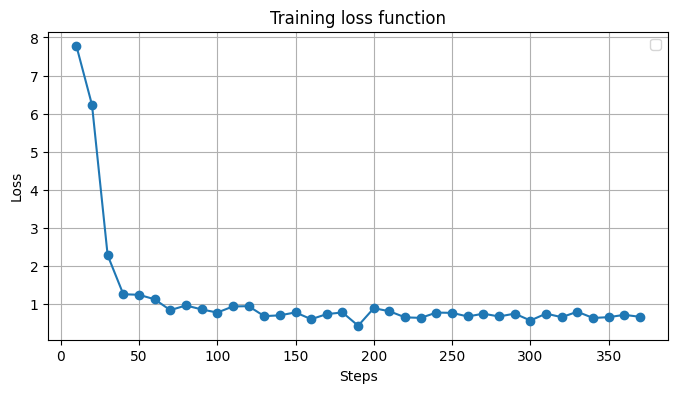

In [16]:
# Đường dẫn
CHECKPOINT_ROOT = "/content/drive/MyDrive/IntroToML - OCR - data/lora_adapter"

# Lấy danh sách các thư mục checkpoint-xxx
checkpoint_dirs = [
    d for d in os.listdir(CHECKPOINT_ROOT)
    if d.startswith("checkpoint-") and os.path.isdir(os.path.join(CHECKPOINT_ROOT, d))
]
checkpoint_dirs = sorted(checkpoint_dirs, key=lambda x: int(x.split('-')[1]))

all_steps = []
all_losses = []

for ckpt in checkpoint_dirs:
    trainer_state_path = os.path.join(CHECKPOINT_ROOT, ckpt, "trainer_state.json")
    if not os.path.exists(trainer_state_path):
        continue
    with open(trainer_state_path, "r", encoding="utf-8") as f:
        state = json.load(f)
    log_history = state.get("log_history", [])
    for log in log_history:
        if "loss" in log and "step" in log:
            all_steps.append(log["step"])
            all_losses.append(log["loss"])

step_loss = {}
for step, loss in zip(all_steps, all_losses):
    step_loss[step] = loss
steps_sorted = sorted(step_loss.keys())
losses_sorted = [step_loss[s] for s in steps_sorted]

# Vẽ biểu đồ Loss function
plt.figure(figsize=(8,4))
plt.plot(steps_sorted, losses_sorted, marker='o')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training loss function")
plt.legend()
plt.grid(True)
plt.show()

### 9.2 Đánh giá CER trên tập Valid
**Đánh giá** từng checkpoint đã lưu trên tập validation, thực hiện **hợp nhất** mô hình gốc với từng checkpoint và tính toán chỉ số CER cho từng checkpoint. Sau đó vẽ biểu đồ CER theo số bước huấn luyện để quan sát quá trình học.


=== Hợp nhất với checkpoint-100 ===


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/510 [00:00<?, ?it/s]

Đang đánh giá: 100%|██████████| 200/200 [05:11<00:00,  1.56s/it]


CER trung bình: 0.3391

=== Hợp nhất với checkpoint-189 ===


...

CER trung bình: 0.2942

=== Hợp nhất với checkpoint-375 ===


Loading weights:   0%|          | 0/510 [00:00<?, ?it/s]

Đang đánh giá: 100%|██████████| 200/200 [04:36<00:00,  1.38s/it]

CER trung bình: 0.2882



/tmp/ipykernel_4000/1443096228.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


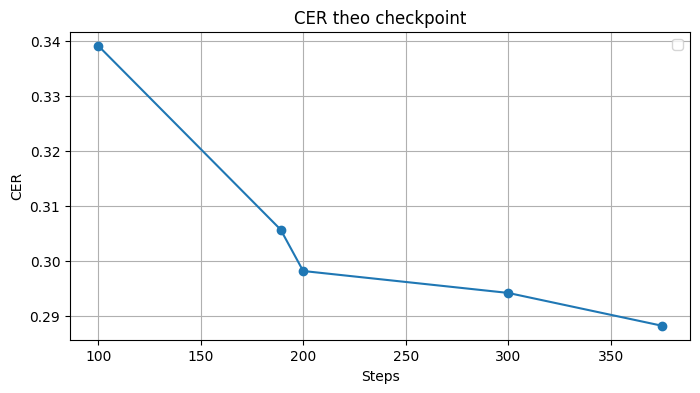

In [4]:
# Đường dẫn
BASE_MODEL = "zai-org/GLM-OCR"
CHECKPOINT_ROOT = "/content/drive/MyDrive/IntroToML - OCR - data/lora_adapter"
VALID_JSON_PATH = "/content/ocr_project/dataset/viet_ocr_valid.json"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Lấy danh sách các thư mục checkpoint-xxx
checkpoint_dirs = [
    d for d in os.listdir(CHECKPOINT_ROOT)
    if re.fullmatch(r"checkpoint-\d+", d) and os.path.isdir(os.path.join(CHECKPOINT_ROOT, d))
]
checkpoint_dirs = sorted(checkpoint_dirs, key=lambda x: int(x.split('-')[1]))

cer_per_ckpt = []
ckpt_steps = []

# Tải dữ liệu của tập Valid
with open(VALID_JSON_PATH, "r", encoding="utf-8") as f:
    valid_samples = json.load(f)

# Thực hiện đánh giá trên Valid
def evaluate_cer_on_valid(model, processor, valid_samples):
    total_cer = 0.0
    for sample in tqdm(valid_samples, desc="Đang đánh giá"):
        img_rel_path = sample["images"][0]
        gt_text = sample["messages"][1]["content"]
        img_path = os.path.join(os.path.dirname(VALID_JSON_PATH), img_rel_path)
        try:
            img = Image.open(img_path)
            pred_text = _run_ocr_glm(model, processor, img)
        except Exception:
            pred_text = ""
        total_cer += calculate_cer(pred_text, gt_text)
    return total_cer / len(valid_samples)

# Thực hiện hợp nhất model gốc + từng checkpoint
for ckpt in checkpoint_dirs:
    lora_adapter = os.path.join(CHECKPOINT_ROOT, ckpt)
    print(f"\n=== Hợp nhất với {ckpt} ===")

    # Hợp nhất mô hình
    cfg = AutoConfig.from_pretrained(BASE_MODEL, trust_remote_code=True)
    module = importlib.import_module(f"transformers.models.{cfg.model_type.replace('-', '_')}")
    gen_cls = next(getattr(module, a) for a in dir(module) if "ForConditionalGeneration" in a)
    base = gen_cls.from_pretrained(BASE_MODEL, trust_remote_code=True, torch_dtype=torch.bfloat16, device_map=DEVICE)
    peft_model = PeftModel.from_pretrained(base, lora_adapter)
    merged = peft_model.merge_and_unload()
    processor = AutoProcessor.from_pretrained(BASE_MODEL, trust_remote_code=True)

    # Đánh giá CER
    cer = evaluate_cer_on_valid(merged, processor, valid_samples)
    print(f"CER trung bình: {cer:.4f}")
    cer_per_ckpt.append(cer)

    # Lấy step từ tên checkpoint
    ckpt_steps.append(int(ckpt.split('-')[1]))

    # Giải phóng bộ nhớ
    del base, peft_model, merged
    torch.cuda.empty_cache()

# Vẽ biểu đồ CER
plt.figure(figsize=(8,4))
plt.plot(ckpt_steps, cer_per_ckpt, marker='o')
plt.xlabel("Steps")
plt.ylabel("CER")
plt.title("CER theo checkpoint")
plt.legend()
plt.grid(True)
plt.show()

### 9.3 Đánh giá trên tập Test
**Hợp nhất** mô hình gốc với `LoRa adapter` từ checkpoint mới nhất tìm được, từ đó thực hiện đánh giá mô hình đã hợp nhất trên tập Test để so sánh với mô hình baseline. Lưu mô hình cuối cùng lên Google Drive để sử dụng cho việc triển khai ứng dụng thực tế.

In [5]:
# Đường dẫn
TEST_JSON_PATH = "/content/ocr_project/dataset/viet_ocr_test.json"
MERGED_MODEL_PATH = "/content/LLaMA-Factory/saves/glm-ocr/lora/sft/merged"
DRIVE_MERGED_PATH = "/content/drive/MyDrive/IntroToML - OCR - data/merged"
CHECKPOINT_ROOT = "/content/drive/MyDrive/IntroToML - OCR - data/lora_adapter"

# Lấy danh sách các thư mục checkpoint-xxx
checkpoint_dirs = [
    d for d in os.listdir(CHECKPOINT_ROOT)
    if d.startswith("checkpoint-") and os.path.isdir(os.path.join(CHECKPOINT_ROOT, d))
]
checkpoint_dirs = sorted(checkpoint_dirs, key=lambda x: int(x.split('-')[1]))

# Checkpoint mới nhất
latest_checkpoint = checkpoint_dirs[-1]
lora_adapter = os.path.join(CHECKPOINT_ROOT, latest_checkpoint)
print(f"Đánh giá trên test với checkpoint: {latest_checkpoint}")

# Hợp nhất mô hình
cfg = AutoConfig.from_pretrained(BASE_MODEL, trust_remote_code=True)
module = importlib.import_module(f"transformers.models.{cfg.model_type.replace('-', '_')}")
gen_cls = next(getattr(module, a) for a in dir(module) if "ForConditionalGeneration" in a)
base = gen_cls.from_pretrained(BASE_MODEL, trust_remote_code=True, torch_dtype=torch.bfloat16, device_map=DEVICE)
peft_model = PeftModel.from_pretrained(base, lora_adapter)
merged = peft_model.merge_and_unload()
processor = AutoProcessor.from_pretrained(BASE_MODEL, trust_remote_code=True)

# Tải dữ liệu của tập Test
with open(TEST_JSON_PATH, "r", encoding="utf-8") as f:
    test_samples = json.load(f)

# Thực hiện đánh giá trên Test
error_logs = []

def evaluate_cer_on_test(model, processor, test_samples):
    total_cer = 0.0
    for sample in tqdm(test_samples, desc="Đang đánh giá"):
        img_rel_path = sample["images"][0]
        gt_text = sample["messages"][1]["content"]
        img_path = os.path.join(os.path.dirname(TEST_JSON_PATH), img_rel_path)
        try:
            img = Image.open(img_path)
            pred_text = _run_ocr_glm(model, processor, img)
        except Exception:
            pred_text = ""
        cer_score = calculate_cer(pred_text, gt_text)
        total_cer += cer_score

        if cer_score > 0:
            error_logs.append({
                "image": os.path.basename(img_path),
                "ground_truth": normalize_text(gt_text),
                "prediction": normalize_text(pred_text),
                "cer_score": round(cer_score, 4)
            })
    return total_cer / len(test_samples)

cer_test = evaluate_cer_on_test(merged, processor, test_samples)
print(f"\nCER trung bình: {cer_test:.4f}")
print(f"Số lượng ảnh dự đoán sai: {len(error_logs)}")

# Lưu trữ kết quả finetune
df_errors = pd.DataFrame(error_logs)
df_errors = df_errors.sort_values(by="cer_score", ascending=False)
report_path = LOCAL_ROOT / 'finetune.csv'
df_errors.to_csv(report_path, index=False, encoding='utf-8-sig')
drive_report_path = Path('/content/drive/MyDrive/IntroToML - OCR - data/finetune.csv')
!cp "{report_path}" "{drive_report_path}"

print(f"Đã lưu lại report của finetune")

# Lưu trữ mô hình đã hợp nhất
os.makedirs(MERGED_MODEL_PATH, exist_ok=True)
merged.save_pretrained(MERGED_MODEL_PATH)
processor.save_pretrained(MERGED_MODEL_PATH)

if os.path.exists(DRIVE_MERGED_PATH):
    shutil.rmtree(DRIVE_MERGED_PATH)
shutil.copytree(MERGED_MODEL_PATH, DRIVE_MERGED_PATH)
print(f"\nĐã lưu mô hình cuối cùng ở: {DRIVE_MERGED_PATH}")

# Giải phóng bộ nhớ
del base, peft_model, merged
torch.cuda.empty_cache()

Đánh giá trên test với checkpoint: checkpoint-375


Loading weights:   0%|          | 0/510 [00:00<?, ?it/s]

Đang đánh giá: 100%|██████████| 200/200 [04:29<00:00,  1.35s/it]



CER trung bình: 0.2972
Số lượng ảnh dự đoán sai: 108
Đã lưu lại report của finetune


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Đã lưu mô hình cuối cùng ở: /content/drive/MyDrive/IntroToML - OCR - data/merged
